In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (10003, 2)
Test Shape: (3080, 2)


In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 943.8 KB


In [6]:
print("\nMissing Values:")
print(train_df.isnull().sum())


Missing Values:
text        0
category    0
dtype: int64


In [7]:
print("\nDuplicate Rows:")
print(train_df.duplicated().sum())


Duplicate Rows:
0


Category distribution

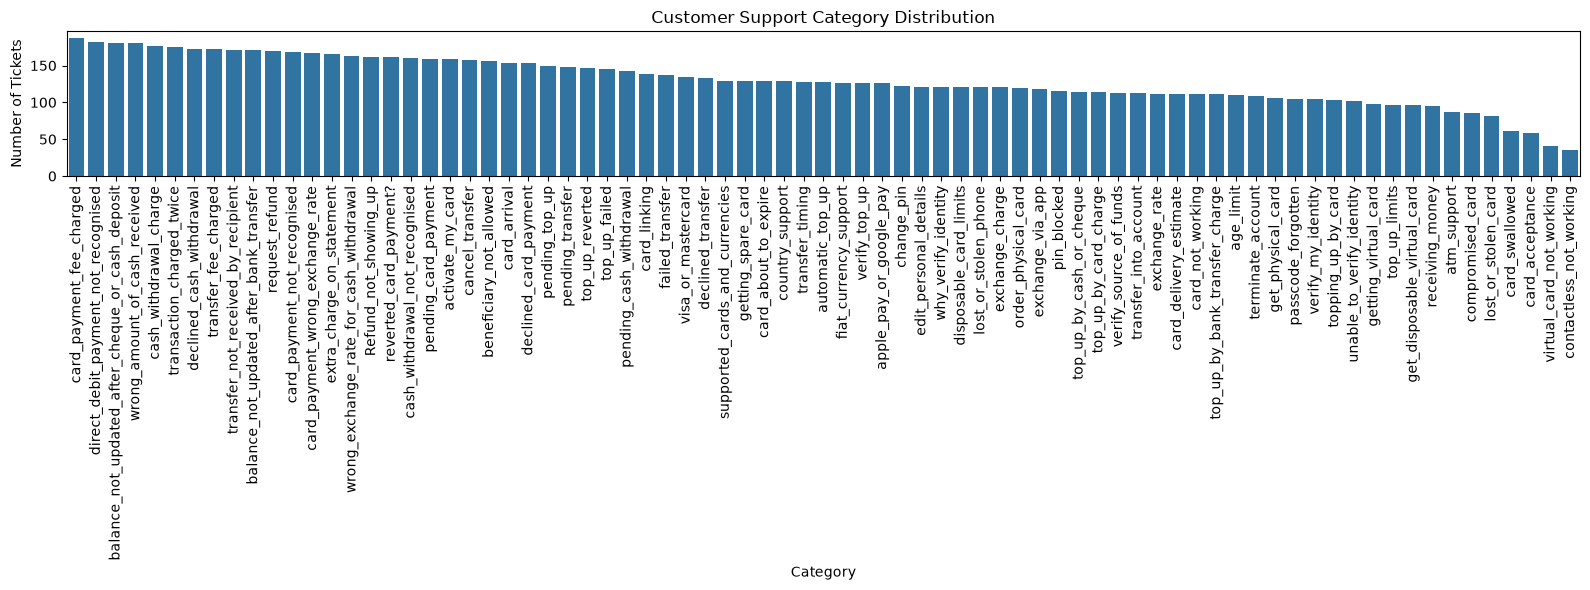

In [10]:
category_counts = train_df["category"].value_counts()

plt.figure(figsize=(16, 6))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Customer Support Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

10 most common and 10 least common categories

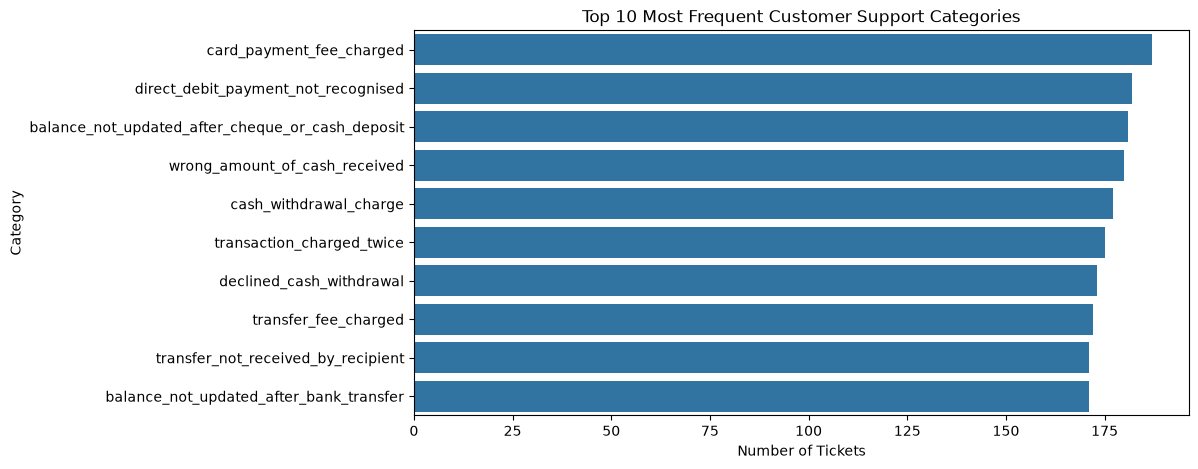

In [13]:
top_10 = train_df["category"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title("Top 10 Most Frequent Customer Support Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.show()

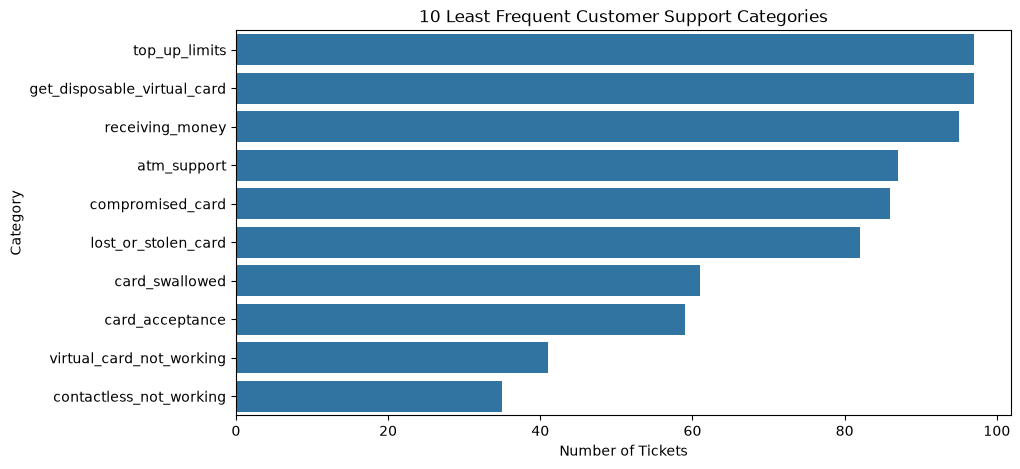

In [14]:
bottom_10 = train_df["category"].value_counts().tail(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=bottom_10.values,
    y=bottom_10.index
)

plt.title("10 Least Frequent Customer Support Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.show()

Text length analysis

count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: text_length, dtype: float64


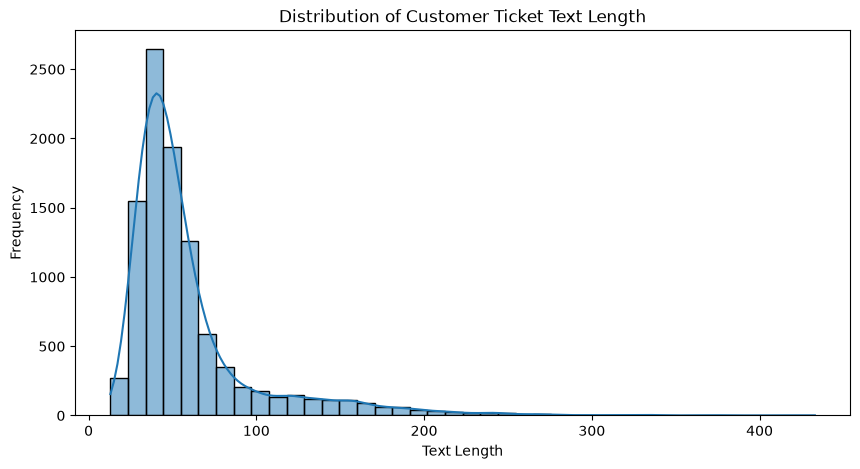

In [11]:
train_df["text_length"] = train_df["text"].str.len()

print(train_df["text_length"].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["text_length"],
    bins=40,
    kde=True
)

plt.title("Distribution of Customer Ticket Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [12]:
for category in train_df["category"].unique()[:5]:
    print("\nCategory:", category)

    samples = train_df[
        train_df["category"] == category
    ]["text"].head(3)

    for text in samples:
        print("-", text)


Category: card_arrival
- I am still waiting on my card?
- What can I do if my card still hasn't arrived after 2 weeks?
- I have been waiting over a week. Is the card still coming?

Category: card_linking
- My card has been found. Is there any way for me to put it back into the app?
- I was able to find my card. How to I go about putting it into my app?
- how do I get my card to show in the app?

Category: exchange_rate
- What is my money worth in other countries?
- Will my money be of equal value when I travel abroad?
- Do you know the rate of exchange?

Category: card_payment_wrong_exchange_rate
- Last Saturday, I was charged extra for the exchange rate on my payment. Is something wrong?
- Hi, I am disappointed to see such a bad exchange rate and hope you can assist me. Would you be able to confirm the official interbank exchange rate for me?
- I think the currency exchange that's been applied is wrong.

Category: extra_charge_on_statement
- Why is there an extra fee on my statement?

Test Data

In [15]:
print("Test Data Information:")
test_df.info()

print("\nTest Missing Values:")
print(test_df.isnull().sum())

print("\nTest Duplicate Rows:")
print(test_df.duplicated().sum())

Test Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      3080 non-null   str  
 1   category  3080 non-null   str  
dtypes: str(2)
memory usage: 272.8 KB

Test Missing Values:
text        0
category    0
dtype: int64

Test Duplicate Rows:
0


Check number of categories

In [16]:
print("Number of unique categories:", train_df["category"].nunique())
print("Number of categories in test:", test_df["category"].nunique())

Number of unique categories: 77
Number of categories in test: 77


In [17]:
print("Train categories not in test:")
print(set(train_df["category"]) - set(test_df["category"]))

print("\nTest categories not in train:")
print(set(test_df["category"]) - set(train_df["category"]))

Train categories not in test:
set()

Test categories not in train:
set()


Analyze category balance

In [18]:
category_stats = (
    train_df["category"]
    .value_counts()
    .reset_index()
)

category_stats.columns = ["category", "count"]

print(category_stats)

print("\nMinimum samples:", category_stats["count"].min())
print("Maximum samples:", category_stats["count"].max())
print("Mean samples:", category_stats["count"].mean())

                                            category  count
0                           card_payment_fee_charged    187
1                direct_debit_payment_not_recognised    182
2   balance_not_updated_after_cheque_or_cash_deposit    181
3                      wrong_amount_of_cash_received    180
4                             cash_withdrawal_charge    177
..                                               ...    ...
72                               lost_or_stolen_card     82
73                                    card_swallowed     61
74                                   card_acceptance     59
75                          virtual_card_not_working     41
76                           contactless_not_working     35

[77 rows x 2 columns]

Minimum samples: 35
Maximum samples: 187
Mean samples: 129.9090909090909


In [19]:
print("Smallest categories:")
print(category_stats.tail(10))

print("\nLargest categories:")
print(category_stats.head(10))

Smallest categories:
                       category  count
67                top_up_limits     97
68  get_disposable_virtual_card     97
69              receiving_money     95
70                  atm_support     87
71             compromised_card     86
72          lost_or_stolen_card     82
73               card_swallowed     61
74              card_acceptance     59
75     virtual_card_not_working     41
76      contactless_not_working     35

Largest categories:
                                           category  count
0                          card_payment_fee_charged    187
1               direct_debit_payment_not_recognised    182
2  balance_not_updated_after_cheque_or_cash_deposit    181
3                     wrong_amount_of_cash_received    180
4                            cash_withdrawal_charge    177
5                         transaction_charged_twice    175
6                          declined_cash_withdrawal    173
7                              transfer_fee_charged    17

Check duplicate text

In [20]:
print("Duplicate texts in train:",
      train_df["text"].duplicated().sum())

print("Duplicate texts in test:",
      test_df["text"].duplicated().sum())

Duplicate texts in train: 0
Duplicate texts in test: 0


In [21]:
train_texts = set(train_df["text"])
test_texts = set(test_df["text"])

overlap = train_texts.intersection(test_texts)

print("Train/Test text overlap:", len(overlap))

Train/Test text overlap: 0


Analyze word count

In [22]:
train_df["word_count"] = train_df["text"].str.split().str.len()

print(train_df["word_count"].describe())

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_count, dtype: float64


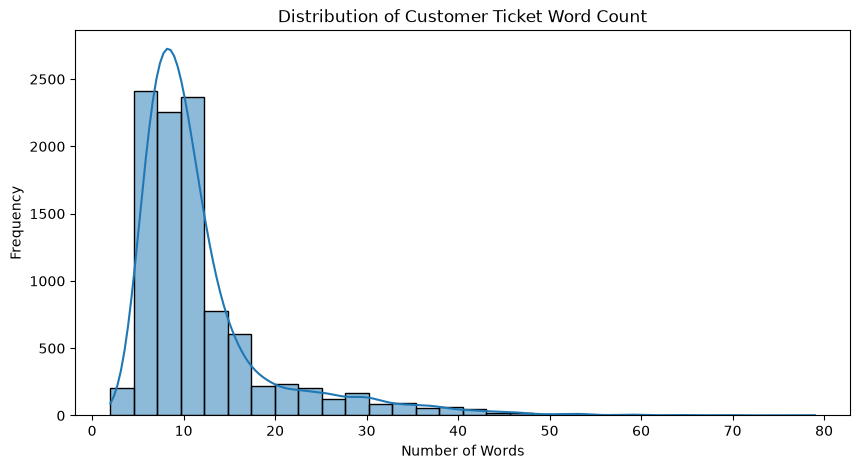

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Ticket Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()